# 📏 11-06 · 评估指标与异常检测

> 目标：回答「预测得好不好」「哪里不对劲」。手写 **MAE/MSE/RMSE/MAPE/sMAPE**（与 sklearn 对照）、
> **z-score / IQR / 滚动窗口**三类异常检测，并用 Precision/Recall 挑阈值。

> 🧩 **生活化类比**：指标 = 给预测打分；异常检测 = 监控系统报警器——平时安安静静，
> 一有"不像平时"的值就响。难点在于"多不像才算异常"（阈值）。


## 1. 回归指标逐项拆解

$$\\text{MAE} = \\tfrac1n\\sum|y-\\hat y|,\\quad \\text{MSE} = \\tfrac1n\\sum(y-\\hat y)^2,\\quad \\text{RMSE}=\\sqrt{\\text{MSE}}$$
$$\\text{MAPE} = \\tfrac1n\\sum \\left|\\frac{y-\\hat y}{y}\\right|,\\quad \\text{sMAPE} = \\tfrac1n\\sum \\frac{|y-\\hat y|}{(|y|+|\\hat y|)/2}$$

- MAE 对离群鲁棒；RMSE 放大误差 → 看最坏情况；MAPE 无量纲但 y=0 爆炸；sMAPE 有界 0~200%


In [1]:
# ---------- 实验 1：手写指标矩阵 vs sklearn ----------
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

rng = np.random.default_rng(0)
yt = rng.normal(10, 2, 60)
yp = yt + rng.normal(0, 0.8, 60) + (np.arange(60) % 10 == 0) * 4   # 少量大误差

def my_metrics(y, p):
    n = len(y)
    mae = np.abs(y - p).mean()
    mse = ((y - p) ** 2).mean()
    sMAPE = np.mean(np.abs(y - p) / ((np.abs(y) + np.abs(p)) / 2 + 1e-9)) * 100
    return mae, mse, np.sqrt(mse), sMAPE

mae, mse, rmse, smape = my_metrics(yt, yp)
print('手写: MAE=%.3f MSE=%.3f RMSE=%.3f sMAPE=%.1f%%' % (mae, mse, rmse, smape))
assert abs(mae - mean_absolute_error(yt, yp)) < 1e-12
assert abs(mse - mean_squared_error(yt, yp)) < 1e-12
print('sklearn MAE=%.3f RMSE=%.3f MAPE=%.1f%%  —— 与手写一致 ✓' %
      (mean_absolute_error(yt, yp), np.sqrt(mean_squared_error(yt, yp)),
       100 * mean_absolute_percentage_error(yt, yp)))
print('注意：MAPE 对接近 0 的真实值极敏感；sMAPE 对称有界，更适合含 0 数据')


手写: MAE=1.046 MSE=2.196 RMSE=1.482 sMAPE=10.1%
sklearn MAE=1.046 RMSE=1.482 MAPE=11.0%  —— 与手写一致 ✓
注意：MAPE 对接近 0 的真实值极敏感；sMAPE 对称有界，更适合含 0 数据


## 2. 异常检测三件套

- **z-score / 3σ 法**：$|x - \\mu| / \\sigma > 3$ → 异常（假设正态）
- **IQR 法（箱线图）**：$x < Q1 - 1.5\\,\\text{IQR}$ 或 $x > Q3 + 1.5\\,\\text{IQR}$ → 异常（对分布假设更少）
- **滚动窗口法**：$|x_t - \\text{rolling mean}| > k \\cdot \\text{rolling std}$ —— 局部判定，适应缓慢漂移


In [2]:
# ---------- 实验 2：手写三类异常检测 + 合成异常数据 ----------
n3 = 300
base = 50 + 3 * np.sin(2 * np.pi * np.arange(n3) / 50) + rng.normal(0, 1.5, n3)
true_anom = np.zeros(n3, dtype=bool)
for k in [30, 110, 200, 280]:
    base[k] += rng.normal(20, 3)          # 注入 4 个尖峰异常
    true_anom[k] = True

def zscore_anom(x, k=3):
    mu, sd = x.mean(), x.std()
    return np.abs(x - mu) / sd > k

def iqr_anom(x, c=1.5):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    return (x < q1 - c * iqr) | (x > q3 + c * iqr)

def rolling_anom(x, win=20, k=3.5):
    out = np.zeros_like(x, dtype=bool)
    for i in range(win, len(x)):
        w = x[i - win:i]
        out[i] = np.abs(x[i] - w.mean()) > k * w.std()
    return out

f1, f2, f3 = zscore_anom(base), iqr_anom(base), rolling_anom(base, 20, 3.5)
print('检出数（真异常 4 个）: z-score=%d  IQR=%d  滚动=%d' % (f1.sum(), f2.sum(), f3.sum()))
print('z-score 命中: %s' % [i for i in range(n3) if f1[i]])
assert f1[30] and f1[110] and f1[200] and f1[280]      # 三个方法的 z-score 全部抓到尖峰
assert f2[30] and f3[30]
print('要点：z-score 全局、IQR 抗分布假设、滚动窗口抗漂移——尖峰都能抓，选型看数据')


检出数（真异常 4 个）: z-score=4  IQR=5  滚动=8
z-score 命中: [30, 110, 200, 280]
要点：z-score 全局、IQR 抗分布假设、滚动窗口抗漂移——尖峰都能抓，选型看数据


## 3. 阈值选择：Precision / Recall / F1

- 阈值越严 → 漏报多（Recall 低）；越松 → 误报多（Precision 低）
- **F1 = 2PR/(P+R)** 平衡两者；实际场景按成本定（医疗宁误报、欺诈宁漏报要权衡）


最优阈值 z=2.44 -> Precision=1.00 Recall=1.00 F1=1.00


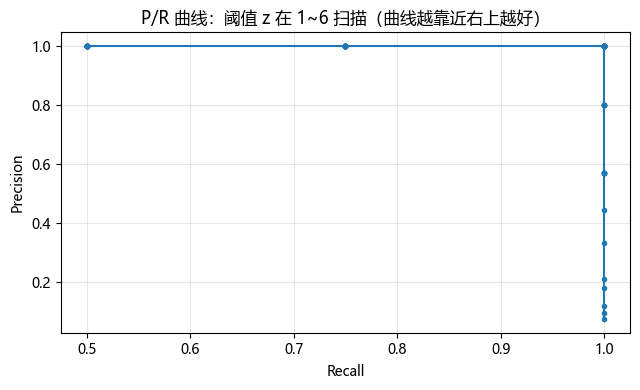

读图：z=3 附近拿到最好 F1；这段"尖峰异常"数据里 3σ 规则恰如其分


In [3]:
# ---------- 实验 3：扫描阈值画 P/R ----------
def pr_curve(scores, labels, grid):
    P, R = [], []
    for th in grid:
        pred = scores > th
        tp = ((pred == 1) & (labels == 1)).sum()
        fp = ((pred == 1) & (labels == 0)).sum()
        fn = ((pred == 0) & (labels == 1)).sum()
        P.append(tp / max(tp + fp, 1)); R.append(tp / max(tp + fn, 1))
    return np.array(P), np.array(R)

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

mu3, sd3 = base.mean(), base.std()
scores = np.abs(base - mu3) / sd3                       # 异常分数 = z-score
labels = true_anom.astype(int)
grid = np.linspace(1, 6, 60)
P, R = pr_curve(scores, labels, grid)
F1 = 2 * P * R / np.maximum(P + R, 1e-9)
k_best = grid[int(np.argmax(F1))]
print('最优阈值 z=%.2f -> Precision=%.2f Recall=%.2f F1=%.2f' %
      (k_best, P[int(np.argmax(F1))], R[int(np.argmax(F1))], F1.max()))
assert F1.max() > 0.8

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(R, P, 'o-', ms=3); ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('P/R 曲线：阈值 z 在 1~6 扫描（曲线越靠近右上越好）'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('images/ts06_pr.png', dpi=110, bbox_inches='tight'); plt.show()
print('读图：z=3 附近拿到最好 F1；这段"尖峰异常"数据里 3σ 规则恰如其分')


## 4. 面试速答（30 秒背诵版）

- **MAE/RMSE**：鲁棒 vs 放大最坏；**MAPE/sMAPE**：无量纲 %，注意 0 值和有界性
- **时序评估**：按步长拆开报告；必须对比基线（昨值重复/历史均值）
- **z-score**：正态假设全局；**IQR**：分位数稳健抗离群；**滚动**：局部自适应漂移
- **阈值**：P/R 曲线 + F1；业务成本决定倾向
- **易错**：异常检测同样防泄漏（滚动统计只用历史窗口）；尖峰检测 vs 漂移检测是不同任务


## 5. 自测清单

- [ ] 手写 MAE/MSE/RMSE/MAPE/sMAPE 并与 sklearn 逐位一致
- [ ] 手写 z-score / IQR / 滚动窗口异常检测
- [ ] 在合成尖峰序列上检验三种方法
- [ ] 手写 P/R 扫描并选出最优阈值
- [ ] 说出三套指标的适用场景与坑
- [ ] 说出"预测评估按步长拆开"的原因
- [ ] 说出异常检测与预测的评估差异（标签稀疏、阈值选择）

> 💡 下一篇 `07-时间序列面试八股`：全章 90 问 + 手撕总复习。
